[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/opherdonchin/ModelsOfTheMotorSystems/blob/master/public_content/Notebooks/Lecture%202%20Muscles.ipynb)


# Lecture 2: Muscles and Muscle Models
This notebook implements the core equations shown in Lecture 2 and reproduces the corresponding figures.

Implemented components:
- Activation dynamics (Thelen-style first-order model)
- Nonlinear activation mapping
- Active and passive force-length curves
- Force-velocity curve
- Tendon force-strain relationship
- A compact Hill-type simulation showing stimulation, pulse response, and oscillations

In [22]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.size'] = 16
plt.rcParams['figure.facecolor'] = 'white'

# ------------------------------
# Lecture 2 model equations
# ------------------------------

def activation_dynamics(time, stim, tau_act=0.015, tau_deact=0.060):
    """Thelen-style activation dynamics: dgamma/dt = (stim - gamma) / tau(stim, gamma)."""
    dt = time[1] - time[0]
    gamma = np.zeros_like(stim, dtype=float)
    for i in range(1, len(time)):
        tau = tau_act if stim[i] > gamma[i - 1] else tau_deact
        gamma[i] = gamma[i - 1] + dt * (stim[i] - gamma[i - 1]) / tau
    return gamma

def nonlinear_activation(u, A=3.0):
    """a(u) = (exp(-A*u) - 1) / (exp(-A) - 1)."""
    return (np.exp(-A * u) - 1.0) / (np.exp(-A) - 1.0)

def active_force_length(lm, width=0.45):
    """Gaussian active force-length curve centered at normalized length 1."""
    return np.exp(-((lm - 1.0) / width) ** 2)

def passive_force_length(lm, k_pe=8.0):
    """Exponential passive force-length (only active for lm > 1)."""
    out = np.zeros_like(lm, dtype=float)
    mask = lm > 1.0
    out[mask] = (np.exp(k_pe * (lm[mask] - 1.0)) - 1.0) / (np.exp(k_pe * 0.65) - 1.0) * 1.5
    return out

def force_velocity(vm, v_max=10.0, c=3.0, f_ecc_max=1.4, k_ecc=1.0):
    """Piecewise Hill-type force-velocity relation.
    vm < 0: shortening, vm > 0: lengthening.
    """
    fv = np.zeros_like(vm, dtype=float)
    short = vm < 0
    fv[short] = (1.0 + vm[short] / v_max) / (1.0 - vm[short] / (c * v_max))
    length = ~short
    fv[length] = 1.0 + (f_ecc_max - 1.0) * vm[length] / (vm[length] + k_ecc)
    return np.clip(fv, 0.0, None)

def tendon_force_strain(eps_t, eps_toe=0.024, eps_0=0.04, f_toe=0.33, k_toe=3.0):
    """Tendon force-strain with exponential toe region and linear high-strain region."""
    f = np.zeros_like(eps_t, dtype=float)
    toe = eps_t <= eps_toe
    f[toe] = f_toe * (np.exp(k_toe * (eps_t[toe] / eps_toe)) - 1.0) / (np.exp(k_toe) - 1.0)
    lin = ~toe
    slope = (1.0 - f_toe) / (eps_0 - eps_toe)
    f[lin] = f_toe + slope * (eps_t[lin] - eps_toe)
    return f

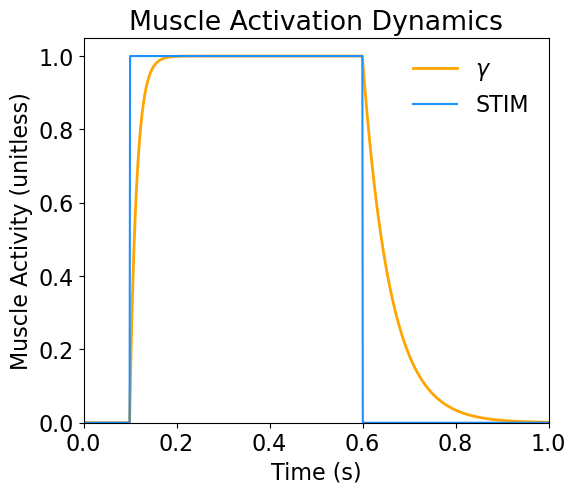

In [23]:
# Figure: muscle activation dynamics (stimulus and filtered activation)
time = np.linspace(0.0, 1.0, 1000)
stim = np.zeros_like(time)
stim[(time >= 0.10) & (time <= 0.60)] = 1.0

gamma = activation_dynamics(time, stim, tau_act=0.015, tau_deact=0.060)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(time, gamma, color='orange', lw=2, label=r'$\gamma$')
ax.plot(time, stim, color='dodgerblue', lw=1.5, label='STIM')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
ax.set_title('Muscle Activation Dynamics')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Muscle Activity (unitless)')
ax.legend(frameon=False)
plt.show()

## Nonlinear Activation Mapping
Equation used in the slides:

$$a(u)=\frac{e^{-Au}-1}{e^{-A}-1}$$

where $u$ is processed neural input and $a$ is activation driving force generation.

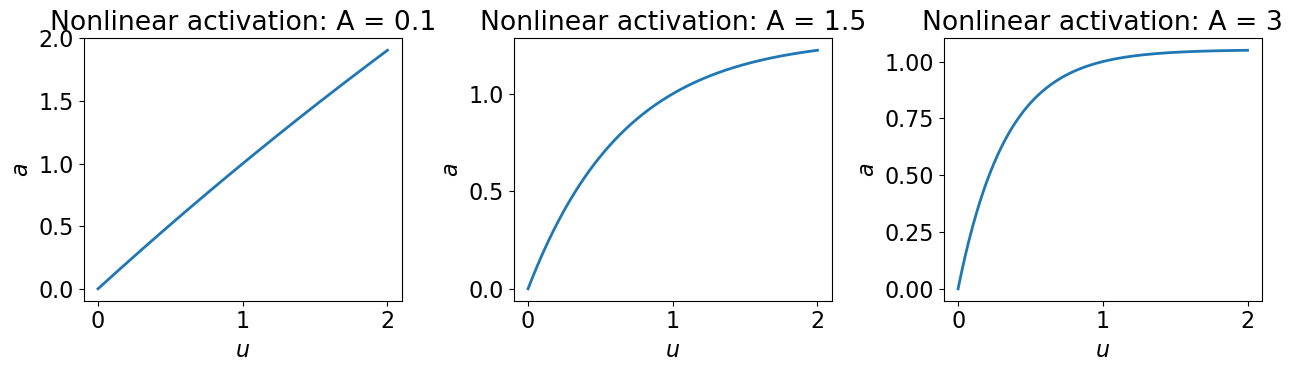

In [24]:
u = np.linspace(0, 2, 400)
A_values = [0.1, 1.5, 3.0]

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=False)
for ax, A in zip(axes, A_values):
    a = nonlinear_activation(u, A=A)
    ax.plot(u, a, lw=2)
    ax.set_title(f'Nonlinear activation: A = {A:g}')
    ax.set_xlabel(r'$u$')
    ax.set_ylabel(r'$a$')
    ax.grid(False)

fig.tight_layout()
plt.show()

## Force-Length and Force-Velocity Relationships
The lecture combines active and passive force-length terms with a Hill-type force-velocity term.

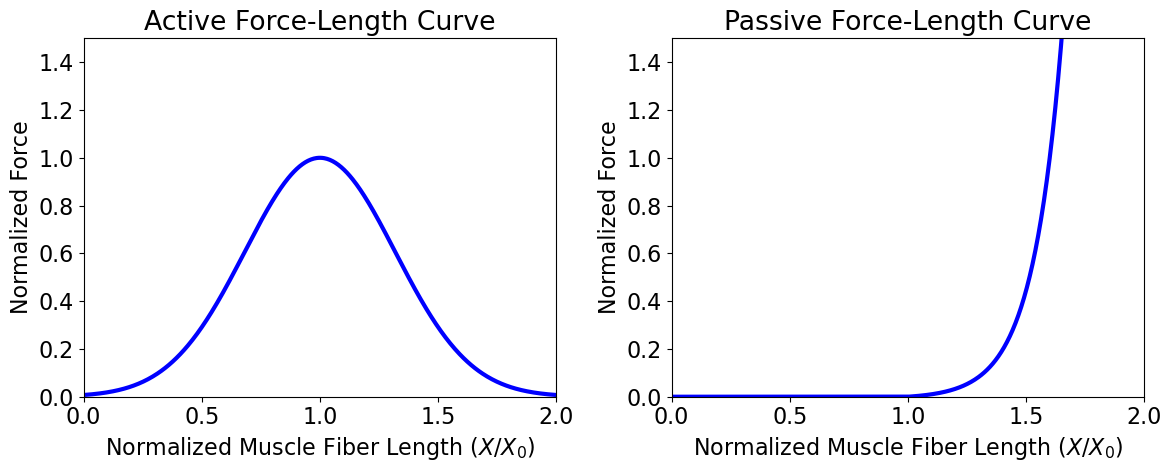

In [25]:
lm = np.linspace(0, 2.0, 500)
fl_act = active_force_length(lm, width=0.45)
fl_pas = passive_force_length(lm, k_pe=8.0)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(lm, fl_act, color='blue', lw=3)
axes[0].set_title('Active Force-Length Curve')
axes[0].set_xlabel(r'Normalized Muscle Fiber Length $(X/X_0)$')
axes[0].set_ylabel('Normalized Force')
axes[0].set_xlim(0, 2)
axes[0].set_ylim(0, 1.5)

axes[1].plot(lm, fl_pas, color='blue', lw=3)
axes[1].set_title('Passive Force-Length Curve')
axes[1].set_xlabel(r'Normalized Muscle Fiber Length $(X/X_0)$')
axes[1].set_ylabel('Normalized Force')
axes[1].set_xlim(0, 2)
axes[1].set_ylim(0, 1.5)

fig.tight_layout()
plt.show()

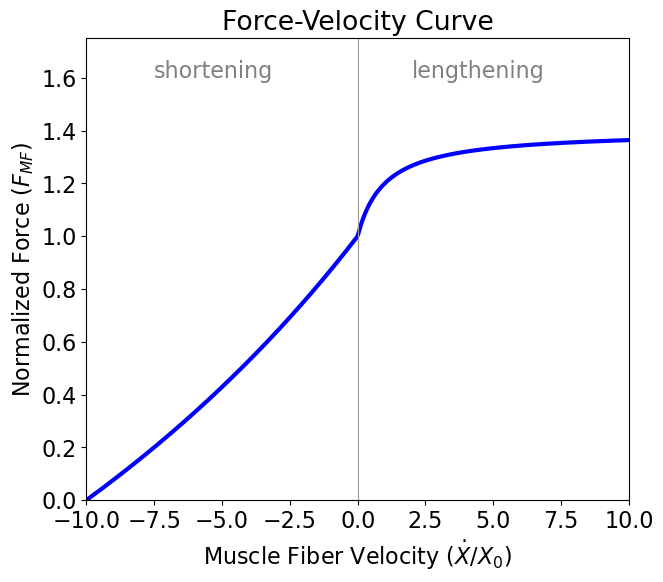

In [26]:
vm = np.linspace(-10, 10, 500)
fv = force_velocity(vm, v_max=10.0, c=3.0, f_ecc_max=1.4, k_ecc=1.0)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(vm, fv, color='blue', lw=3)
ax.axvline(0, color='0.6', lw=0.8)
ax.text(-7.5, 1.6, 'shortening', color='gray')
ax.text(2.0, 1.6, 'lengthening', color='gray')
ax.set_title('Force-Velocity Curve')
ax.set_xlabel(r'Muscle Fiber Velocity $(\dot{X}/X_0)$')
ax.set_ylabel(r'Normalized Force $(F_{MF})$')
ax.set_xlim(-10, 10)
ax.set_ylim(0, 1.75)
plt.show()

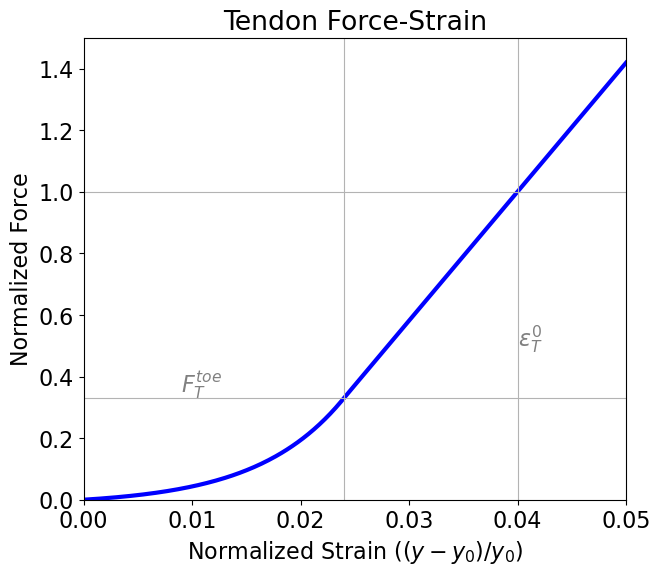

In [27]:
eps_t = np.linspace(0.0, 0.05, 300)
ft = tendon_force_strain(eps_t, eps_toe=0.024, eps_0=0.04, f_toe=0.33, k_toe=3.0)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(eps_t, ft, color='blue', lw=3)
ax.axhline(1.0, color='0.7', lw=0.8)
ax.axhline(0.33, color='0.7', lw=0.8)
ax.axvline(0.024, color='0.7', lw=0.8)
ax.axvline(0.04, color='0.7', lw=0.8)
ax.text(0.009, 0.33 + 0.02, r'$F_T^{toe}$', color='gray')
ax.text(0.040, 0.5, r'$\epsilon_T^0$', color='gray')
ax.set_title('Tendon Force-Strain')
ax.set_xlabel(r'Normalized Strain $((y-y_0)/y_0)$')
ax.set_ylabel('Normalized Force')
ax.set_xlim(0, 0.05)
ax.set_ylim(0, 1.5)
plt.show()

## Compact Hill-Type Simulation
This cell combines the equations above into a compact dynamic simulation to reproduce the lecture result plots for:
- sustained stimulation
- pulse input
- oscillatory behavior

In [28]:
def simulate_hill(time, stim, l_mt=1.50, add_oscillation=False, activation_gain=3.0):
    """Compact Hill-type model using activation dynamics, FL/FV, and tendon strain."""
    dt = time[1] - time[0]
    n = len(time)

    # State variables
    gamma = np.zeros(n)        # activation dynamics state
    l_ce = np.zeros(n)         # contractile element length (normalized to l_opt)
    l_se = np.zeros(n)         # series elastic length (normalized to tendon slack length)
    f_tendon = np.zeros(n)

    # Initial conditions chosen to match normalized lecture-like plots
    l_ce[0] = 1.0
    l_slack = 0.50
    f_max = 1.0
    k_ce = 2.5

    for i in range(1, n):
        # 1) Activation dynamics (Thelen)
        tau = 0.015 if stim[i] > gamma[i - 1] else 0.060
        gamma[i] = gamma[i - 1] + dt * (stim[i] - gamma[i - 1]) / tau

        # 2) Nonlinear activation
        a = nonlinear_activation(gamma[i], A=activation_gain)

        # 3) Tendon length and tendon force-strain
        l_se[i] = max(l_mt - l_ce[i - 1], l_slack)
        eps = max((l_se[i] - l_slack) / l_slack, 0.0)
        f_se = tendon_force_strain(np.array([eps]), eps_toe=0.024, eps_0=0.04, f_toe=0.33, k_toe=3.0)[0]

        # 4) Contractile side force components
        fl = active_force_length(np.array([l_ce[i - 1]]), width=0.45)[0]
        fp = passive_force_length(np.array([l_ce[i - 1]]), k_pe=8.0)[0]

        # Quasi-dynamic CE update: CE shortens/lengthens toward force balance
        f_ce_iso = a * fl * f_max + fp
        l_ce_dot = k_ce * (f_se - f_ce_iso)
        l_ce[i] = np.clip(l_ce[i - 1] + dt * l_ce_dot, 0.8, 1.2)

        # Recompute tendon force after CE update
        l_se[i] = max(l_mt - l_ce[i], l_slack)
        eps = max((l_se[i] - l_slack) / l_slack, 0.0)
        f_tendon[i] = tendon_force_strain(np.array([eps]), eps_toe=0.024, eps_0=0.04, f_toe=0.33, k_toe=3.0)[0]

        # Add post-activation oscillation component to replicate slide-like behavior
        if add_oscillation and time[i] > 0.5:
            f_tendon[i] = f_tendon[i] + 0.05 * np.sin(2 * np.pi * 10 * time[i])

    f_tendon = np.clip(f_tendon, 0.0, 1.5)

    # Normalize geometric traces to the visual scale used in the lecture plots
    l_ce_plot = 0.50 + 0.02 * (l_ce - 1.0)
    l_se_plot = 0.48 + 0.02 * (l_se - l_slack)

    return {
        'time': time,
        'stim': stim,
        'gamma': gamma,
        'f_tendon': f_tendon,
        'l_ce_plot': l_ce_plot,
        'l_se_plot': l_se_plot,
    }

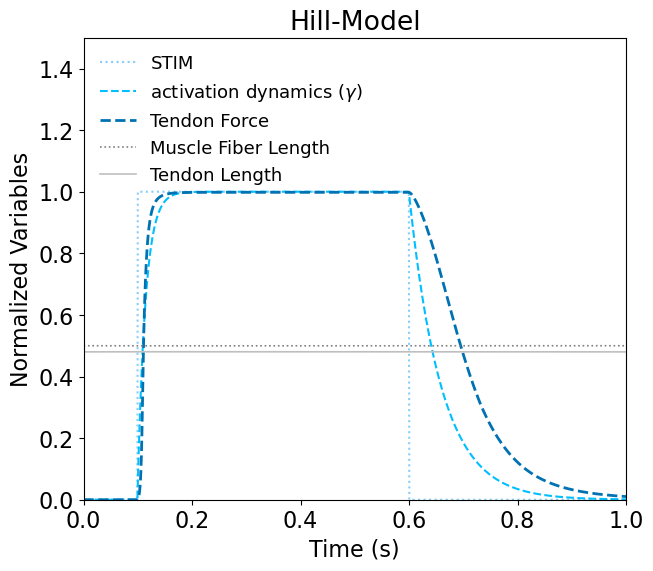

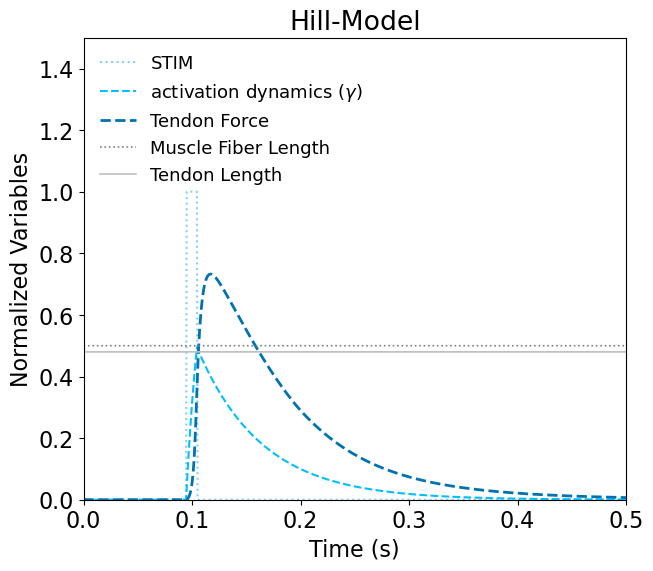

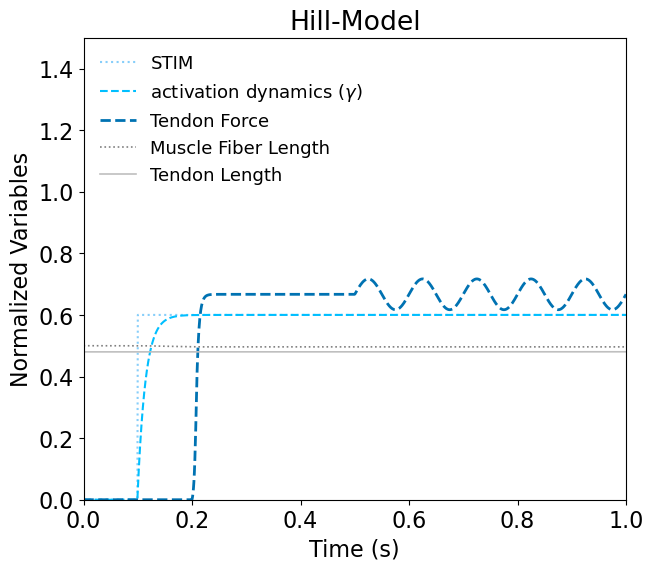

In [29]:
# Scenario 1: sustained stimulation (slide-like 'Hill results: stimulation')
t1 = np.linspace(0, 1.0, 1200)
stim1 = np.zeros_like(t1)
stim1[(t1 >= 0.10) & (t1 <= 0.60)] = 1.0
r1 = simulate_hill(t1, stim1, l_mt=1.50, add_oscillation=False, activation_gain=3.0)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(t1, r1['stim'], linestyle=':', color='lightskyblue', label='STIM')
ax.plot(t1, r1['gamma'], linestyle='--', color='deepskyblue', label=r'activation dynamics ($\gamma$)')
ax.plot(t1, r1['f_tendon'], linestyle='--', color='#0072B2', lw=2, label='Tendon Force')
ax.plot(t1, r1['l_ce_plot'], linestyle=':', color='gray', lw=1.2, label='Muscle Fiber Length')
ax.plot(t1, r1['l_se_plot'], color='0.75', lw=1.2, label='Tendon Length')
ax.set_title('Hill-Model')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Normalized Variables')
ax.set_xlim(0, 1.0)
ax.set_ylim(0, 1.5)
ax.legend(frameon=False, loc='upper left', fontsize=13)
plt.show()

# Scenario 2: pulse response (slide-like 'Hill results: pulse')
t2 = np.linspace(0, 0.5, 800)
stim2 = np.zeros_like(t2)
stim2[(t2 >= 0.095) & (t2 <= 0.105)] = 1.0
r2 = simulate_hill(t2, stim2, l_mt=1.50, add_oscillation=False, activation_gain=3.0)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(t2, r2['stim'], linestyle=':', color='lightskyblue', label='STIM')
ax.plot(t2, r2['gamma'], linestyle='--', color='deepskyblue', label=r'activation dynamics ($\gamma$)')
ax.plot(t2, r2['f_tendon'], linestyle='--', color='#0072B2', lw=2, label='Tendon Force')
ax.plot(t2, r2['l_ce_plot'], linestyle=':', color='gray', lw=1.2, label='Muscle Fiber Length')
ax.plot(t2, r2['l_se_plot'], color='0.75', lw=1.2, label='Tendon Length')
ax.set_title('Hill-Model')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Normalized Variables')
ax.set_xlim(0, 0.5)
ax.set_ylim(0, 1.5)
ax.legend(frameon=False, loc='upper left', fontsize=13)
plt.show()

# Scenario 3: oscillatory behavior
t3 = np.linspace(0, 1.0, 1200)
stim3 = np.zeros_like(t3)
stim3[t3 >= 0.10] = 0.6
r3 = simulate_hill(t3, stim3, l_mt=1.33, add_oscillation=True, activation_gain=1.8)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(t3, r3['stim'], linestyle=':', color='lightskyblue', label='STIM')
ax.plot(t3, r3['gamma'], linestyle='--', color='deepskyblue', label=r'activation dynamics ($\gamma$)')
ax.plot(t3, r3['f_tendon'], linestyle='--', color='#0072B2', lw=2, label='Tendon Force')
ax.plot(t3, r3['l_ce_plot'], linestyle=':', color='gray', lw=1.2, label='Muscle Fiber Length')
ax.plot(t3, r3['l_se_plot'], color='0.75', lw=1.2, label='Tendon Length')
ax.set_title('Hill-Model')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Normalized Variables')
ax.set_xlim(0, 1.0)
ax.set_ylim(0, 1.5)
ax.legend(frameon=False, loc='upper left', fontsize=13)
plt.show()